In [ ]:
from lokigi.site import SiteProblem

In [ ]:
problem = SiteProblem()

In [ ]:
problem.describe_models(available_only=True)

=== Supported Healthcare Location Models ===

ID: p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance for the entire population.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.

To run a model, use: prob.solve_pmedian(p=3) or similar.


In [ ]:
problem.describe_models(available_only=False)

=== Healthcare Location Models ===

ID: p_median
Name: P-Median (Average Distance Minimizer)
Goal: Minimize the total travel distance for the entire population.
When to use: Best for general primary care where you want the 'average' patient to have the shortest trip possible.
Main Trade-off: Can leave remote or rural patients with very long travel times in favor of urban density.
Status: Supported

ID: mclp
Name: Maximal Coverage Location Problem (MCLP)
Goal: Maximize the number of people within a specific time/distance 'threshold' (e.g., 15 minutes).
When to use: Best for emergency services (Ambulance/ER) where getting there within a 'Golden Hour' is more important than the average trip time.
Main Trade-off: Does not care how far away people are once they are outside the threshold.
Status: Planned

ID: lscp
Name: Location Set Covering Location Problem (LSCP)
Goal: Find the minimum number of facilities needed to cover *everyone* within a certain distance.
When to use: Best for universa

In [ ]:
problem.show_demand_format()


--- Expected Demand DataFrame Format ---
Note: Each row represents a unique demand location (e.g., LSOA).
site_id_col     | demand_col
------------------------------
LSOA 1          | 25        
LSOA 2          | 15        
...             | ...       
----------------------------------------



In [ ]:
problem.show_travel_format()


--- Expected Travel/Cost DataFrame Format ---
Note: Rows are sources, columns are destinations.
source_id       | dest_1          | dest_2         
--------------------------------------------------
source_1        | 22.6            | 16.3           
source_2        | 15.1            | 17.1           
...             | ...             | ...            
--------------------------------------------

For example, if using LSOAs, your dataframe might look like this:
source_id       | E01000259       | E01000314      
--------------------------------------------------
Brighton and Hove 027E | 22.6            | 16.3           
Brighton and Hove 005C | 15.1            | 17.1           
...             | ...             | ...            
--------------------------------------------

Or if you've defined your site names, it might look like this:
source_id       | Site 1          | Site 1         
--------------------------------------------------
Brighton and Hove 027E | 22.6            | 16.3

## Add the required data

In [ ]:
problem.add_demand("../../sample_data/brighton_demand.csv", demand_col="demand", location_id_col="LSOA")

In [ ]:
problem.show_demand()

     Unnamed: 0                    LSOA  demand
0             0  Brighton and Hove 027E    3627
1             1  Brighton and Hove 027F    2323
2             2  Brighton and Hove 027A    2596
3             3  Brighton and Hove 029E    3132
4             4  Brighton and Hove 029D    2883
..          ...                     ...     ...
160         160  Brighton and Hove 012A    2497
161         161  Brighton and Hove 005C    2570
162         162  Brighton and Hove 012B    2051
163         163  Brighton and Hove 005A    1164
164         164  Brighton and Hove 005B    1097

[165 rows x 3 columns]


In [ ]:
problem.add_sites("../../sample_data/brighton_sites.geojson", candidate_id_col="site")

In [ ]:
problem.show_sites()

     site                   geometry
0  Site 1  POINT (-0.19544 50.84511)
1  Site 2  POINT (-0.13365 50.84435)
2  Site 3  POINT (-0.10763 50.83347)
3  Site 4  POINT (-0.17652 50.83075)
4  Site 5  POINT (-0.11961 50.86597)
5  Site 6  POINT (-0.17259 50.85758)


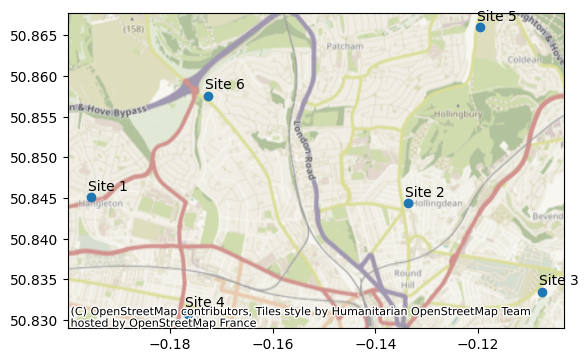

In [ ]:
problem.plot_sites()